In [ ]:
# Task
# Data Loading and Cleaning:

# Load the dataset using Pandas.
# Perform basic data cleaning (handling missing values, incorrect data types, etc.).
# Exploratory Data Analysis (EDA):

# Use Pandas to summarize the key statistics of the dataset.
# Identify unique values, ranges, and distribution of data.
# Visualization Tasks:

# Species Distribution: Use a bar chart to show the distribution of penguin species.
# Flipper Length vs. Body Mass: Create a scatter plot to analyze the relationship between flipper length and body mass, color-coded by species.
# Island Distribution: Visualize the count of penguins on each island using a pie chart.
# Sex Distribution within Species: Create grouped bar charts showing the distribution of sex within each penguin species.
# Heatmap of Correlations: Plot a heatmap to visualize the correlations between numerical variables.
# Boxplots for Measurements: Generate boxplots for flipper length, body mass, and bill measurements, segmented by species.
# Histograms of Measurements: Create histograms to show the distribution of key measurements (bill length, bill depth, flipper length).
# Insightful Visualizations:

# Combine multiple plots into a single figure (using subplots) to compare different aspects of the data.
# Use Seaborn’s pairplot to visualize pairwise relationships in the dataset.


In [1]:
import pandas as pd

df = pd.read_csv('PalmerPenguinsDataset.csv')

print("Shape:", df.shape)
print(df.columns)
display(df.head())

Shape: (344, 8)
Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex', 'year'],
      dtype='object')


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [2]:
# ---- missing values check ----
print("Missing values:")
print(df.isna().sum())

# ---- basic cleaning ----
# remove rows missing key measurements
df_clean = df.dropna(subset=[
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
    "sex"
]).copy()

print("\nShape after cleaning:", df_clean.shape)

# ensure numeric (safety)
num_cols = ["bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g"]
df_clean[num_cols] = df_clean[num_cols].apply(pd.to_numeric, errors="coerce")

display(df_clean.head())

Missing values:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

Shape after cleaning: (333, 8)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


In [3]:
# ---- summary statistics ----
display(df_clean.describe())

# ---- categorical overview ----
print("\nUnique species:", df_clean["species"].unique())
print("Unique islands:", df_clean["island"].unique())
print("Unique sex:", df_clean["sex"].unique())

# ---- counts ----
print("\nSpecies counts:")
print(df_clean["species"].value_counts())

print("\nIsland counts:")
print(df_clean["island"].value_counts())

print("\nSex counts:")
print(df_clean["sex"].value_counts())

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,333.000000,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057,2008.042042
std,5.468668,1.969235,14.015765,805.215802,0.812944
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.500000,15.600000,190.000000,3550.000000,2007.000000
50%,44.500000,17.300000,197.000000,4050.000000,2008.000000
75%,48.600000,18.700000,213.000000,4775.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000



Unique species: ['Adelie' 'Gentoo' 'Chinstrap']
Unique islands: ['Torgersen' 'Biscoe' 'Dream']
Unique sex: ['male' 'female']

Species counts:
species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

Island counts:
island
Biscoe       163
Dream        123
Torgersen     47
Name: count, dtype: int64

Sex counts:
sex
male      168
female    165
Name: count, dtype: int64


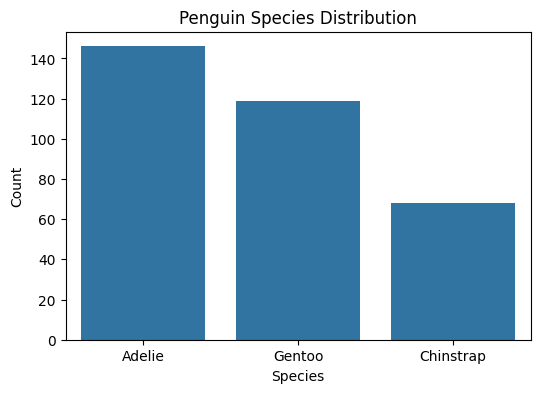

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(data=df_clean, x="species")

plt.title("Penguin Species Distribution")
plt.xlabel("Species")
plt.ylabel("Count")

plt.show()

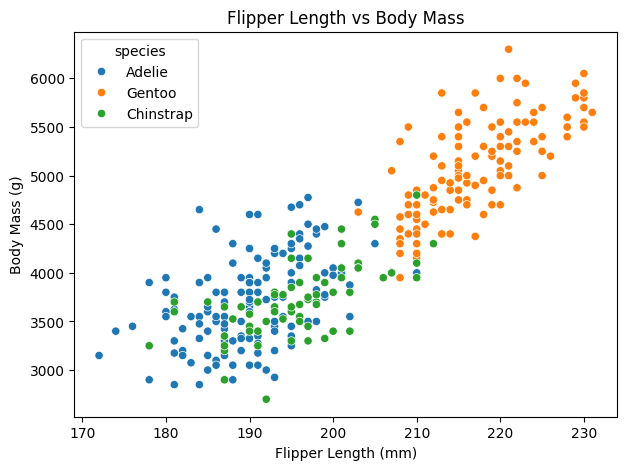

In [5]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df_clean,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="species"
)

plt.title("Flipper Length vs Body Mass")
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Body Mass (g)")

plt.show()

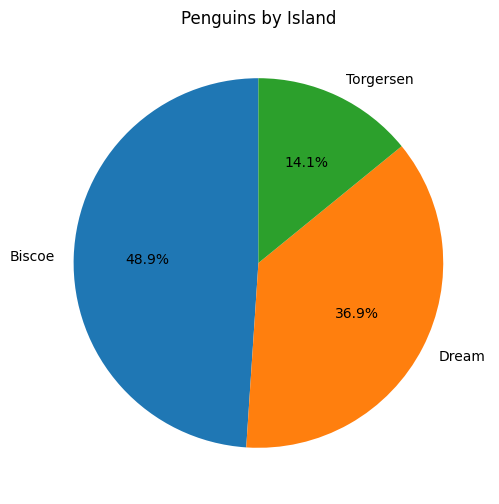

In [6]:
island_counts = df_clean["island"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    island_counts,
    labels=island_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Penguins by Island")

plt.show()

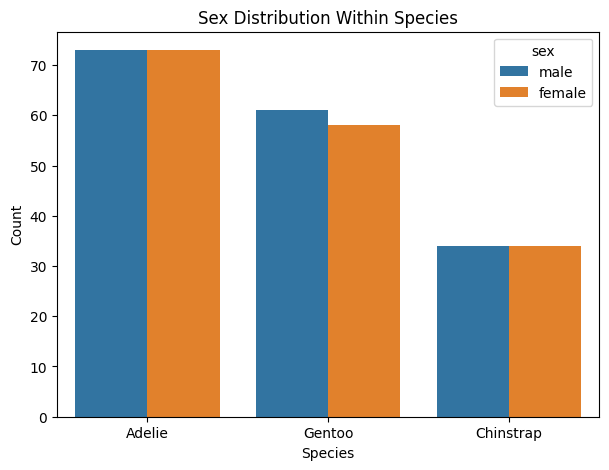

In [7]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df_clean,
    x="species",
    hue="sex"
)

plt.title("Sex Distribution Within Species")
plt.xlabel("Species")
plt.ylabel("Count")

plt.show()

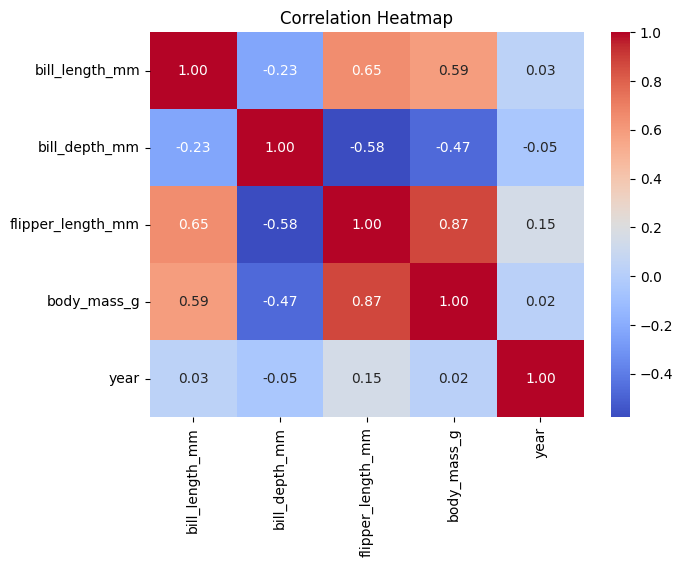

In [8]:
plt.figure(figsize=(7,5))

corr = df_clean.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

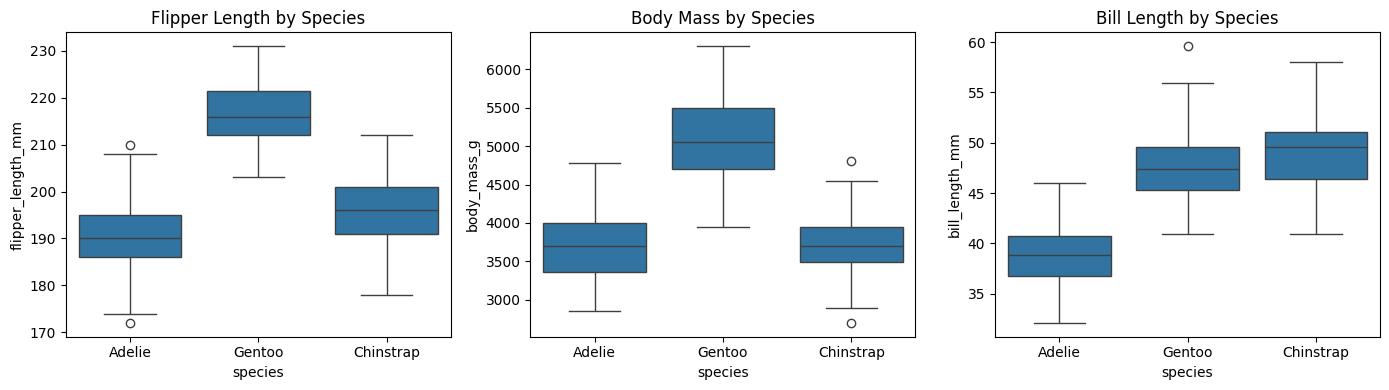

In [9]:
plt.figure(figsize=(14,4))

plt.subplot(1,3,1)
sns.boxplot(data=df_clean, x="species", y="flipper_length_mm")
plt.title("Flipper Length by Species")

plt.subplot(1,3,2)
sns.boxplot(data=df_clean, x="species", y="body_mass_g")
plt.title("Body Mass by Species")

plt.subplot(1,3,3)
sns.boxplot(data=df_clean, x="species", y="bill_length_mm")
plt.title("Bill Length by Species")

plt.tight_layout()
plt.show()

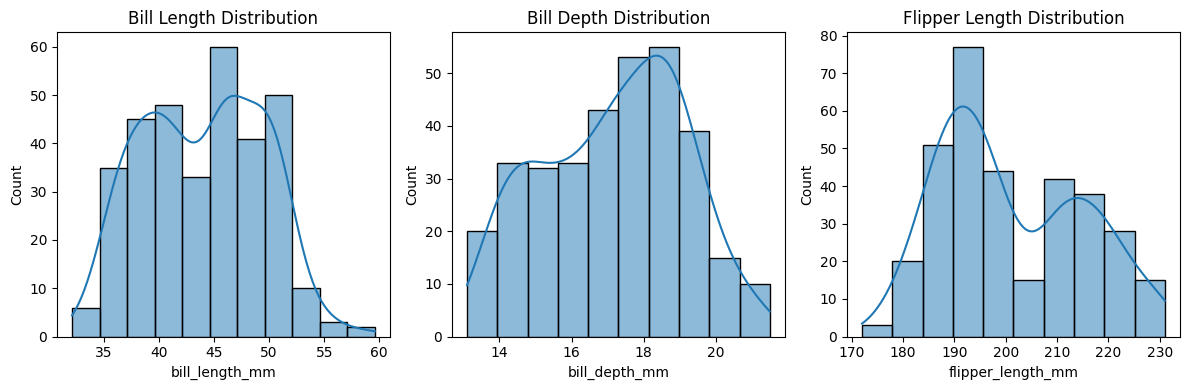

In [10]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.histplot(df_clean["bill_length_mm"], kde=True)
plt.title("Bill Length Distribution")

plt.subplot(1,3,2)
sns.histplot(df_clean["bill_depth_mm"], kde=True)
plt.title("Bill Depth Distribution")

plt.subplot(1,3,3)
sns.histplot(df_clean["flipper_length_mm"], kde=True)
plt.title("Flipper Length Distribution")

plt.tight_layout()
plt.show()

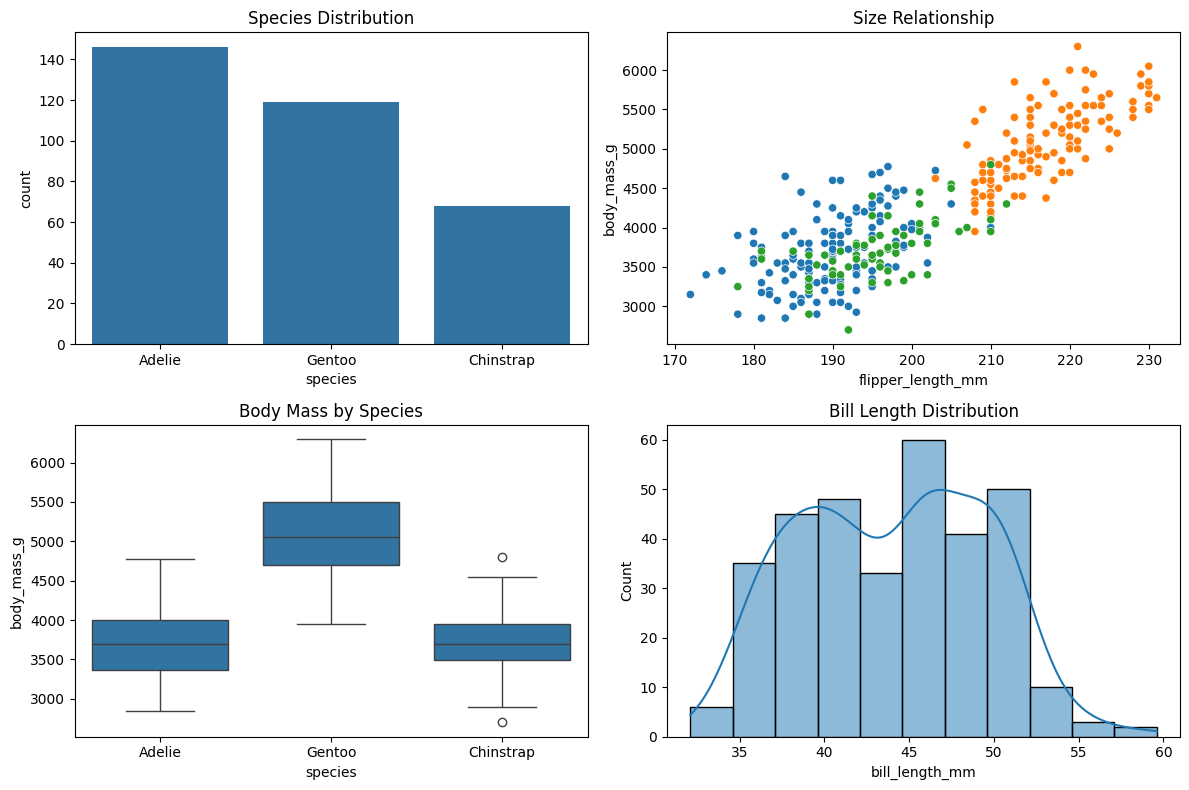

In [11]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
sns.countplot(data=df_clean, x="species")
plt.title("Species Distribution")

plt.subplot(2,2,2)
sns.scatterplot(data=df_clean, x="flipper_length_mm", y="body_mass_g", hue="species", legend=False)
plt.title("Size Relationship")

plt.subplot(2,2,3)
sns.boxplot(data=df_clean, x="species", y="body_mass_g")
plt.title("Body Mass by Species")

plt.subplot(2,2,4)
sns.histplot(df_clean["bill_length_mm"], kde=True)
plt.title("Bill Length Distribution")

plt.tight_layout()
plt.show()

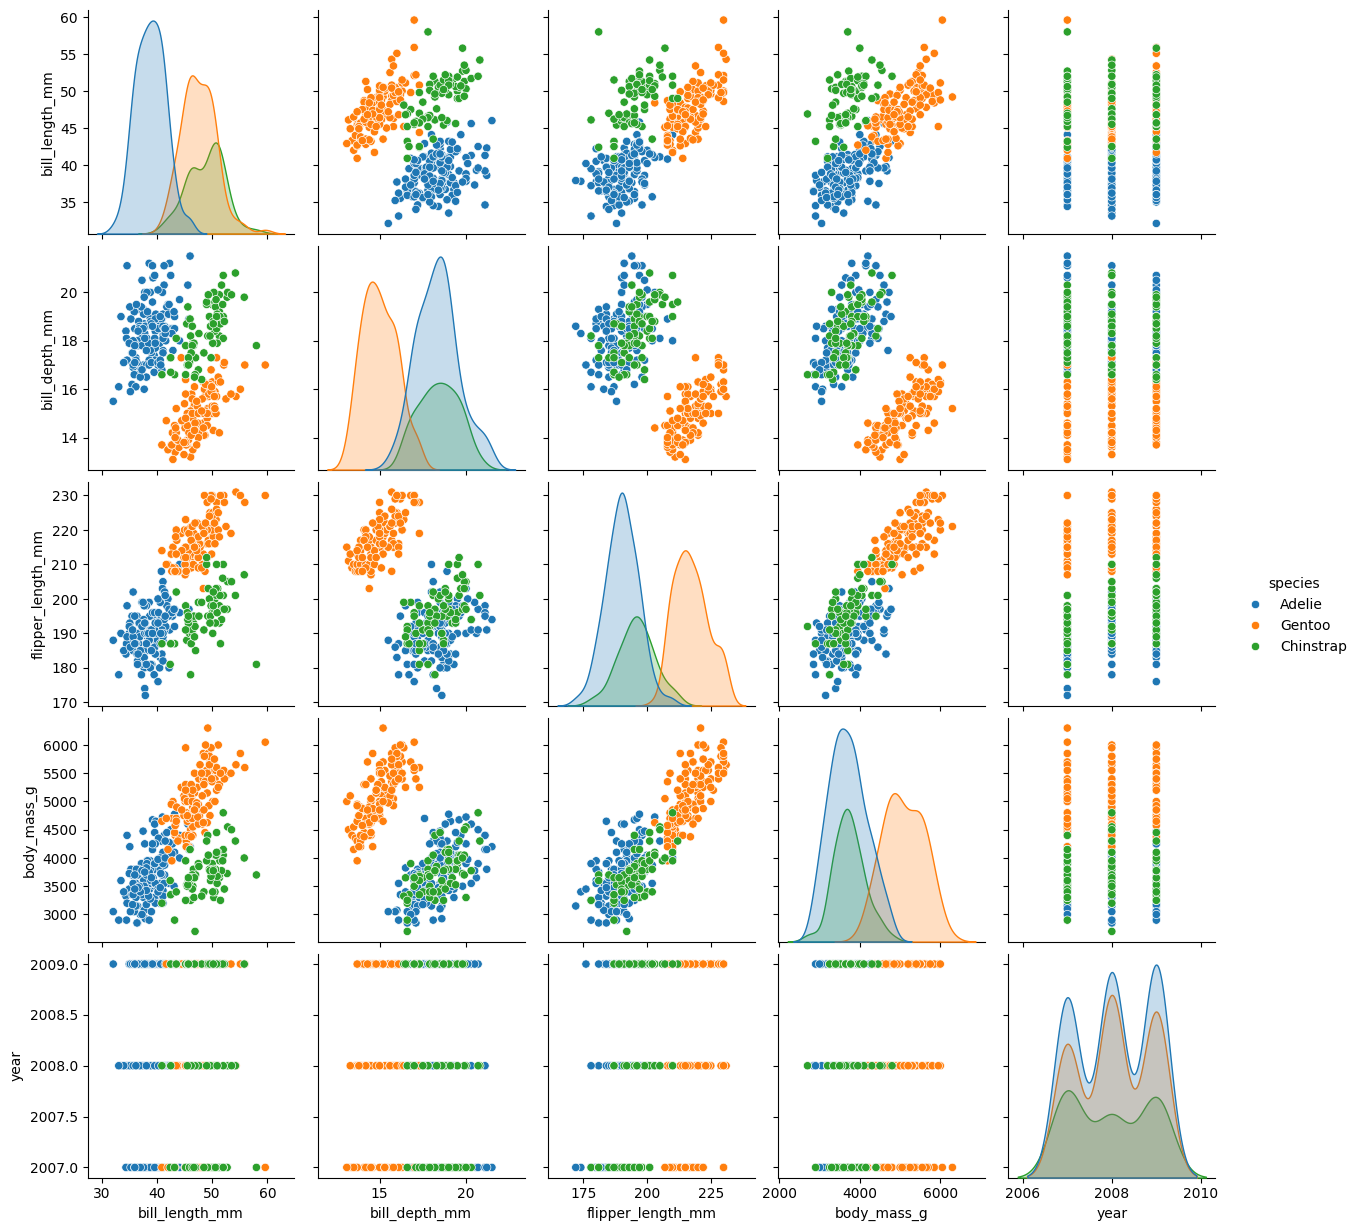

In [12]:
sns.pairplot(
    df_clean,
    hue="species",
    diag_kind="kde"
)
plt.show()

In [ ]:
# The dataset contains measurements for three penguin species: Adelie, Gentoo, and Chinstrap. After cleaning, 333 observations were analyzed.

# Adelie is the most common species, while Chinstrap is the least common. Most penguins are located on Biscoe island.

# Visualizations show a strong positive relationship between flipper length and body mass. Gentoo penguins are the largest, Adelie are the smallest, and Chinstrap fall in between.

# Correlation analysis confirms that flipper length and body mass are highly related, making them strong indicators of penguin size and species differences.

# Boxplots and pairplots reveal clear separation between species based on physical measurements, indicating these features can effectively distinguish penguin species.

# Overall, the analysis shows that body measurements are strong predictors of penguin species and provide clear biological differences between groups.